# Impact vector ψ(θ) and feasible impact set Ψ

$$\psi(\theta) = \mathbb{E}_{z \sim q_{\text{dep}}}\left[2\alpha_z\left(\sigma(\alpha_z^\top\theta) - \tfrac{1}{2}\right)\right] \in \mathbb{R}^k$$

$$\Psi = \{\psi(\theta) : \theta \in \mathbb{R}^k\} \subseteq \mathbb{R}^k$$

Welfare rewrites as $W_n(\theta) = \theta_n^\top \psi(\theta)$, so $\psi$ is a **sufficient statistic** for welfare impact. This notebook explores the geometry of $\Psi$ through simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import expit as sigmoid
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

rng = np.random.default_rng(42)

def psi(theta, alpha_queries):
    """
    Compute ψ(θ) = E_z[2 α_z (σ(α_z^T θ) − 1/2)].
    alpha_queries: (Q, k)
    theta:         (k,)
    Returns:       (k,)
    """
    logits = alpha_queries @ theta          # (Q,)
    weights = 2 * (sigmoid(logits) - 0.5)  # (Q,)
    return (alpha_queries * weights[:, None]).mean(axis=0)

def psi_batch(thetas, alpha_queries):
    """
    Vectorised: thetas (M, k) → psi_vals (M, k).
    """
    logits  = thetas @ alpha_queries.T          # (M, Q)
    weights = 2 * (sigmoid(logits) - 0.5)       # (M, Q)
    return (weights[:, :, None] * alpha_queries[None]).mean(axis=1)  # (M, k)

def make_query_dist(k, Q, kind="gaussian", seed=0):
    """
    Generate Q query vectors in R^k.
    kind: 'gaussian', 'sparse' (each α has 2 nonzero entries ±1), 'uniform_sphere'
    """
    r = np.random.default_rng(seed)
    if kind == "gaussian":
        return r.standard_normal((Q, k))
    elif kind == "sparse":
        A = np.zeros((Q, k))
        for i in range(Q):
            i_, j_ = r.choice(k, size=2, replace=False)
            A[i, i_] = 1.0
            A[i, j_] = -1.0
        return A
    elif kind == "uniform_sphere":
        A = r.standard_normal((Q, k))
        return A / np.linalg.norm(A, axis=1, keepdims=True)
    else:
        raise ValueError(kind)

print("Setup complete.")

Setup complete.


## 1. Basic properties of ψ

**Anti-symmetry:** $\psi(-\theta) = -\psi(\theta)$, because $\sigma(-x) - \tfrac{1}{2} = -(\sigma(x) - \tfrac{1}{2})$.

**Zero:** $\psi(0) = 0$, since $\sigma(0) = \tfrac{1}{2}$.

**Boundedness:** $|\sigma(x)-\tfrac{1}{2}| \leq \tfrac{1}{2}$, so $\|\psi(\theta)\| \leq \mathbb{E}[\|\alpha_z\|]$.

**Jacobian:** $\nabla_\theta \psi(\theta) = \mathbb{E}[2\alpha_z\alpha_z^\top v(\alpha_z^\top\theta)]$ where $v(t)=\sigma(t)(1-\sigma(t))$. This is twice the Fisher information matrix — always PSD, so $\psi$ is a local diffeomorphism.

In [3]:
# ── Verify basic properties numerically ───────────────────────────────────
k, Q = 4, 5000
A = make_query_dist(k, Q, kind="gaussian")
theta_test = rng.standard_normal(k)

p_pos = psi(theta_test, A)
p_neg = psi(-theta_test, A)
print(f"Anti-symmetry  ψ(θ) + ψ(−θ) = {p_pos + p_neg}  (should be ~0)")
print(f"Zero at origin ψ(0)           = {psi(np.zeros(k), A)}  (should be ~0)")

bound = np.linalg.norm(A, axis=1).mean()
print(f"Bound E[||α||] = {bound:.4f}  ||ψ(θ)|| = {np.linalg.norm(p_pos):.4f}")

# Jacobian via finite differences
eps = 1e-5
J_fd = np.array([(psi(theta_test + eps*np.eye(k)[i], A) -
                   psi(theta_test - eps*np.eye(k)[i], A)) / (2*eps)
                  for i in range(k)]).T  # (k, k)
logits = A @ theta_test
v = sigmoid(logits) * (1 - sigmoid(logits))
J_analytic = 2 * (A * v[:, None]).T @ A / Q
print(f"\nJacobian max error (FD vs analytic): {np.abs(J_fd - J_analytic).max():.2e}")
print(f"Jacobian eigenvalues (all > 0 = PSD): {np.linalg.eigvalsh(J_analytic).round(4)}")

Anti-symmetry  ψ(θ) + ψ(−θ) = [4.16333634e-17 0.00000000e+00 0.00000000e+00 0.00000000e+00]  (should be ~0)
Zero at origin ψ(0)           = [0. 0. 0. 0.]  (should be ~0)
Bound E[||α||] = 1.8743  ||ψ(θ)|| = 0.5496

Jacobian max error (FD vs analytic): 1.11e-10
Jacobian eigenvalues (all > 0 = PSD): [0.1671 0.3297 0.3419 0.3434]


## 2. Geometry of Ψ in 2D

For $k=2$ we can directly visualize $\Psi$ by sweeping $\theta$ over a grid and plotting $\psi(\theta)$.

KeyboardInterrupt: 

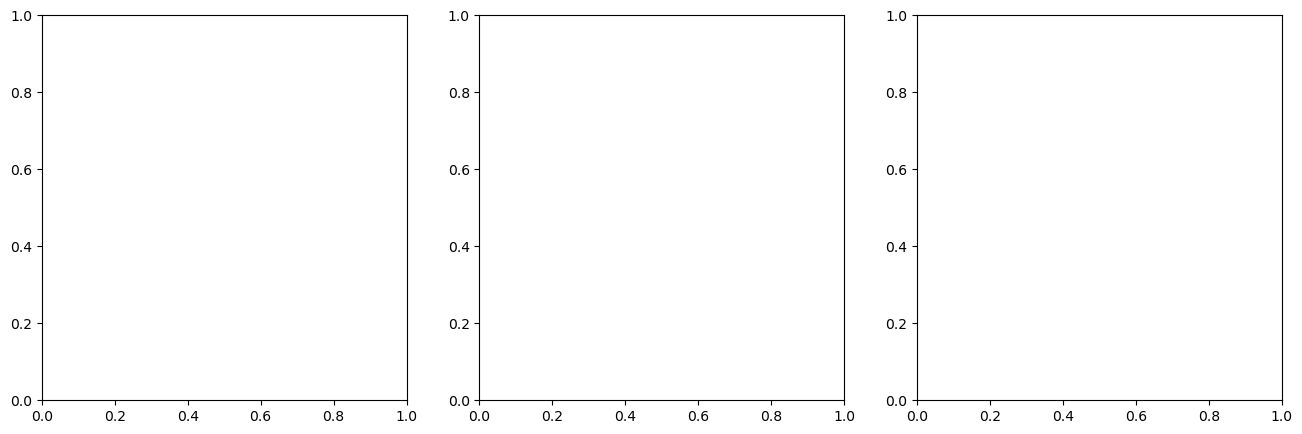

In [4]:
k2, Q2 = 2, 10000

# Sweep θ in polar coordinates at many radii and angles
angles = np.linspace(0, 2*np.pi, 360, endpoint=False)
radii  = np.concatenate([np.linspace(0, 0.5, 20),
                          np.linspace(0.5, 5, 50),
                          np.geomspace(5, 200, 40)])
thetas_polar = np.array([[r * np.cos(a), r * np.sin(a)]
                          for r in radii for a in angles])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, kind, title in zip(axes,
                            ["gaussian", "sparse", "uniform_sphere"],
                            ["Gaussian queries", "Sparse ±1 queries", "Uniform sphere queries"]):
    A2 = make_query_dist(k2, Q2, kind=kind)
    psi_vals = psi_batch(thetas_polar, A2)       # (M, 2)

    # Color by ||θ||
    norms = np.linalg.norm(thetas_polar, axis=1)
    sc = ax.scatter(psi_vals[:, 0], psi_vals[:, 1],
                    c=np.log1p(norms), cmap="viridis", s=0.5, alpha=0.6)

    # Boundary: take limit as r→∞ for each angle
    big_r = 500
    boundary_thetas = np.array([[big_r*np.cos(a), big_r*np.sin(a)] for a in angles])
    boundary_psi = psi_batch(boundary_thetas, A2)
    ax.plot(np.append(boundary_psi[:, 0], boundary_psi[0, 0]),
            np.append(boundary_psi[:, 1], boundary_psi[0, 1]),
            'r-', linewidth=2, label='boundary (||θ||→∞)')

    ax.scatter([0], [0], c='black', s=40, zorder=5, label='ψ(0)=0')
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='log(1+||θ||)')

plt.suptitle(r"Feasible impact set $\Psi$ in 2D for different query distributions",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Boundary of Ψ

As $\|\theta\| \to \infty$ in direction $\hat{u}$, $\sigma(\alpha_z^\top\theta) \to \mathbf{1}[\alpha_z^\top \hat{u} > 0]$, so:

$$\partial\Psi \ni \psi^\infty(\hat{u}) = \mathbb{E}_{z}\left[2\alpha_z \cdot \mathbf{1}[\alpha_z^\top \hat{u} > 0]\right] - \mathbb{E}_z[\alpha_z]$$

The boundary is the image of the unit sphere $S^{k-1}$ under this limiting map — a **star-shaped** set whose shape depends entirely on the query distribution.

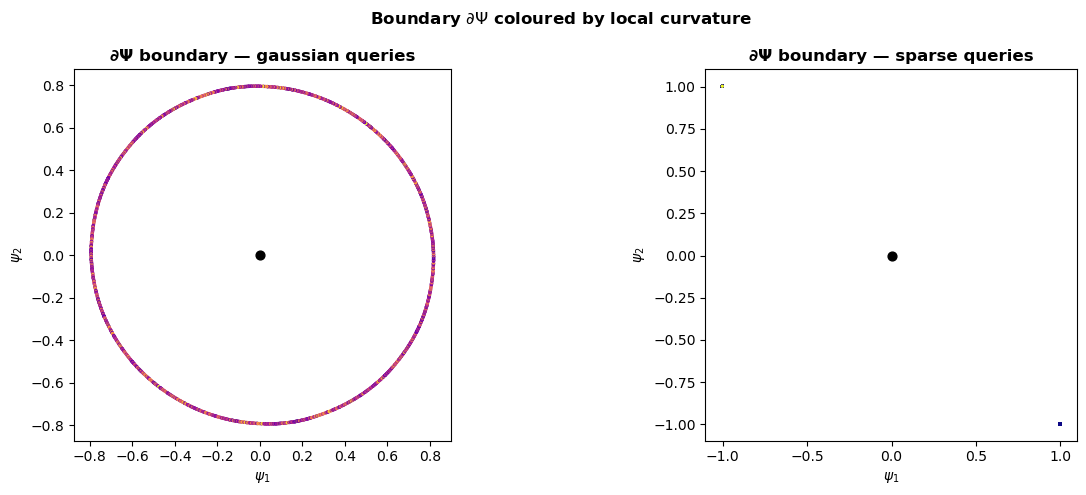

In [4]:
# ── Boundary analysis: how many distinct sign-pattern regions exist? ───────
k2, Q2 = 2, 5000
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, kind in zip(axes, ["gaussian", "sparse"]):
    A2 = make_query_dist(k2, Q2, kind=kind)

    angles_fine = np.linspace(0, 2*np.pi, 2000, endpoint=False)
    unit_dirs   = np.c_[np.cos(angles_fine), np.sin(angles_fine)]

    # Exact boundary
    signs = np.sign(unit_dirs @ A2.T)  # (D, Q)  ∈ {-1, 0, +1}
    bdy   = (A2[None] * (signs > 0)[:, :, None]).mean(axis=1) * 2  # (D, k)

    # Color boundary by curvature (finite-diff angle change)
    db = np.diff(bdy, axis=0)
    curv = np.linalg.norm(db, axis=1)
    ax.scatter(bdy[:-1, 0], bdy[:-1, 1], c=curv, cmap="plasma", s=2)
    ax.plot([bdy[-1, 0], bdy[0, 0]], [bdy[-1, 1], bdy[0, 1]], 'gray', lw=0.5)
    ax.scatter([0], [0], c='black', s=40, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(f"∂Ψ boundary — {kind} queries", fontweight="bold")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")

plt.suptitle(r"Boundary $\partial\Psi$ coloured by local curvature",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 4. ψ as a bijection: injectivity and the role of the Fisher matrix

Since the Jacobian $\nabla_\theta\psi = 2J(\theta)$ is PSD for all $\theta$, $\psi$ is a **local diffeomorphism**. In practice it appears globally injective: two different $\theta$'s produce different impacts.

Min ||ψ(θ1)−ψ(θ2)|| / ||θ1−θ2||: 0.144321
(Would be 0 if non-injective for any pair)


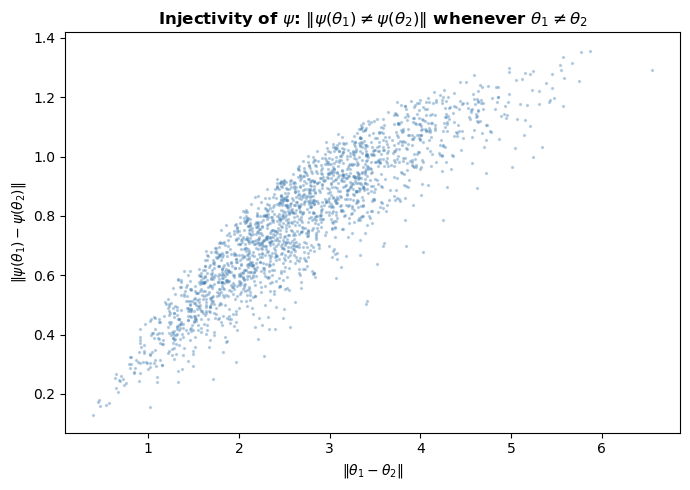

In [5]:
# ── Injectivity check: ||ψ(θ1) - ψ(θ2)|| vs ||θ1 - θ2|| ─────────────────
k_inj, Q_inj = 4, 5000
A_inj = make_query_dist(k_inj, Q_inj, kind="gaussian")

M = 2000
thetas1 = rng.standard_normal((M, k_inj))
thetas2 = rng.standard_normal((M, k_inj))

psi1 = psi_batch(thetas1, A_inj)
psi2 = psi_batch(thetas2, A_inj)

d_theta = np.linalg.norm(thetas1 - thetas2, axis=1)
d_psi   = np.linalg.norm(psi1 - psi2, axis=1)

# Any near-zero d_psi with nonzero d_theta would violate injectivity
print(f"Min ||ψ(θ1)−ψ(θ2)|| / ||θ1−θ2||: {(d_psi / d_theta).min():.6f}")
print(f"(Would be 0 if non-injective for any pair)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(d_theta, d_psi, s=2, alpha=0.3, color="steelblue")
ax.set_xlabel(r"$\|\theta_1 - \theta_2\|$")
ax.set_ylabel(r"$\|\psi(\theta_1) - \psi(\theta_2)\|$")
ax.set_title(r"Injectivity of $\psi$: $\|\psi(\theta_1)\neq\psi(\theta_2)\|$ whenever $\theta_1\neq\theta_2$",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Geometry of Ψ in 3D

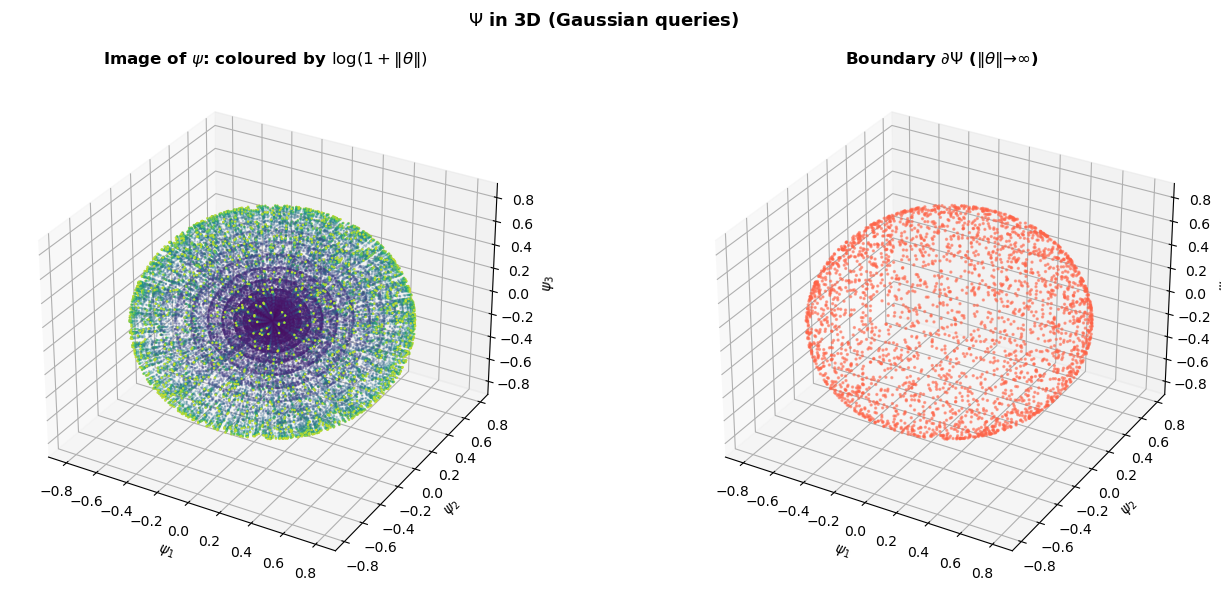

In [6]:
k3, Q3 = 3, 8000
A3 = make_query_dist(k3, Q3, kind="gaussian")

# Sample θ uniformly on spheres of varying radii
n_dirs   = 3000
raw      = rng.standard_normal((n_dirs, k3))
unit_dirs3 = raw / np.linalg.norm(raw, axis=1, keepdims=True)
radii3   = np.geomspace(0.01, 100, 30)

all_thetas3 = np.vstack([r * unit_dirs3 for r in radii3])
all_psi3    = psi_batch(all_thetas3, A3)
norms3      = np.linalg.norm(all_thetas3, axis=1)

# Boundary surface
big_dirs   = 500 * unit_dirs3
bdy3       = psi_batch(big_dirs, A3)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc = ax1.scatter(all_psi3[:, 0], all_psi3[:, 1], all_psi3[:, 2],
                  c=np.log1p(norms3), cmap='viridis', s=0.5, alpha=0.3)
ax1.set_title(r"Image of $\psi$: coloured by $\log(1+\|\theta\|)$", fontweight="bold")
ax1.set_xlabel(r"$\psi_1$"); ax1.set_ylabel(r"$\psi_2$"); ax1.set_zlabel(r"$\psi_3$")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(bdy3[:, 0], bdy3[:, 1], bdy3[:, 2],
             c='tomato', s=2, alpha=0.5)
ax2.set_title(r"Boundary $\partial\Psi$ ($\|\theta\|\to\infty$)", fontweight="bold")
ax2.set_xlabel(r"$\psi_1$"); ax2.set_ylabel(r"$\psi_2$"); ax2.set_zlabel(r"$\psi_3$")

plt.suptitle(r"$\Psi$ in 3D (Gaussian queries)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Welfare representation: W_n(θ) = θ_n^T ψ(θ)

Because welfare is linear in $\psi$, the **feasible welfare set** for a population of agents is:

$$\mathcal{W} = \{(W_1(\theta), \ldots, W_N(\theta)) : \theta \in \mathbb{R}^k\} \subset \mathbb{R}^N$$

The shape of $\mathcal{W}$ determines the welfare tradeoffs available. We visualize it for $N=2$ agents (Pareto frontier) in 2D.

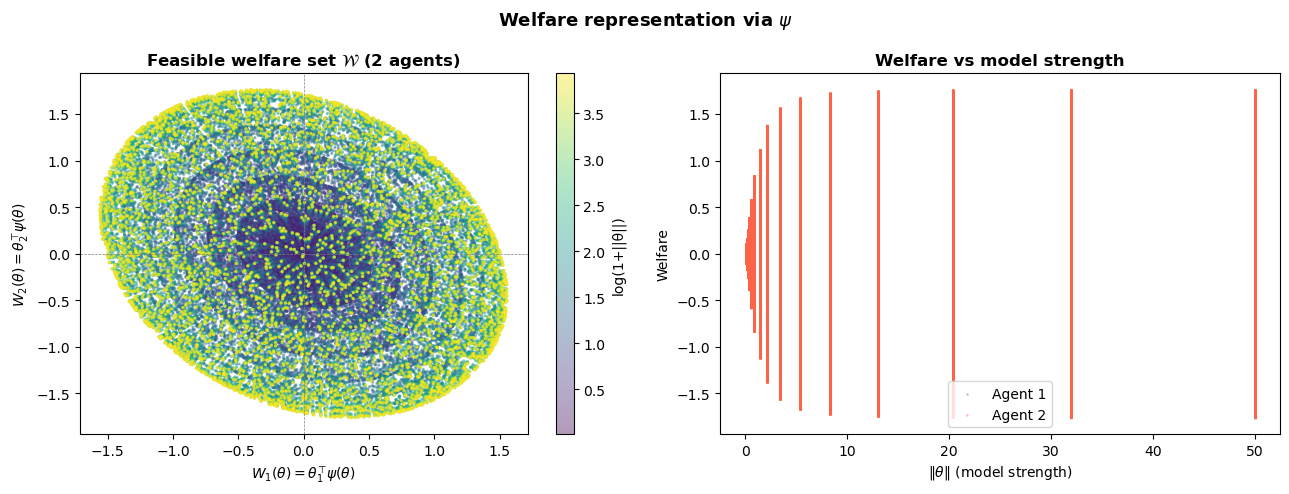

In [7]:
k_w, Q_w, N_agents = 3, 5000, 2
A_w = make_query_dist(k_w, Q_w, kind="gaussian")

# Two agents with different preference vectors
agent_thetas = rng.standard_normal((N_agents, k_w))

# Sweep deployment parameter θ
n_sweep = 5000
raw_sweep = rng.standard_normal((n_sweep, k_w))
radii_sweep = np.geomspace(0.01, 50, 20)
all_deploy = np.vstack([r * raw_sweep / np.linalg.norm(raw_sweep, axis=1, keepdims=True)
                        for r in radii_sweep])

psi_vals = psi_batch(all_deploy, A_w)      # (M, k)
W = psi_vals @ agent_thetas.T              # (M, N)  W[m,n] = θ_n^T ψ(θ_m)

norms_deploy = np.linalg.norm(all_deploy, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: feasible welfare set
sc = axes[0].scatter(W[:, 0], W[:, 1], c=np.log1p(norms_deploy),
                      cmap='viridis', s=2, alpha=0.4)
axes[0].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[0].axvline(0, color='gray', lw=0.5, linestyle='--')
axes[0].set_xlabel(r"$W_1(\theta) = \theta_1^\top\psi(\theta)$")
axes[0].set_ylabel(r"$W_2(\theta) = \theta_2^\top\psi(\theta)$")
axes[0].set_title("Feasible welfare set $\\mathcal{W}$ (2 agents)", fontweight="bold")
plt.colorbar(sc, ax=axes[0], label='log(1+||θ||)')

# Panel 2: welfare vs ||θ|| for each agent
axes[1].scatter(norms_deploy, W[:, 0], s=1, alpha=0.3, color='steelblue', label='Agent 1')
axes[1].scatter(norms_deploy, W[:, 1], s=1, alpha=0.3, color='tomato',    label='Agent 2')
axes[1].set_xlabel(r"$\|\theta\|$ (model strength)")
axes[1].set_ylabel("Welfare")
axes[1].set_title("Welfare vs model strength", fontweight="bold")
axes[1].legend()

plt.suptitle(r"Welfare representation via $\psi$", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 7. How the query distribution shapes Ψ

The query distribution $q_{\text{dep}}$ is the sole determinant of $\Psi$'s shape. Here we vary the concentration/anisotropy of $q$ and watch the boundary change.

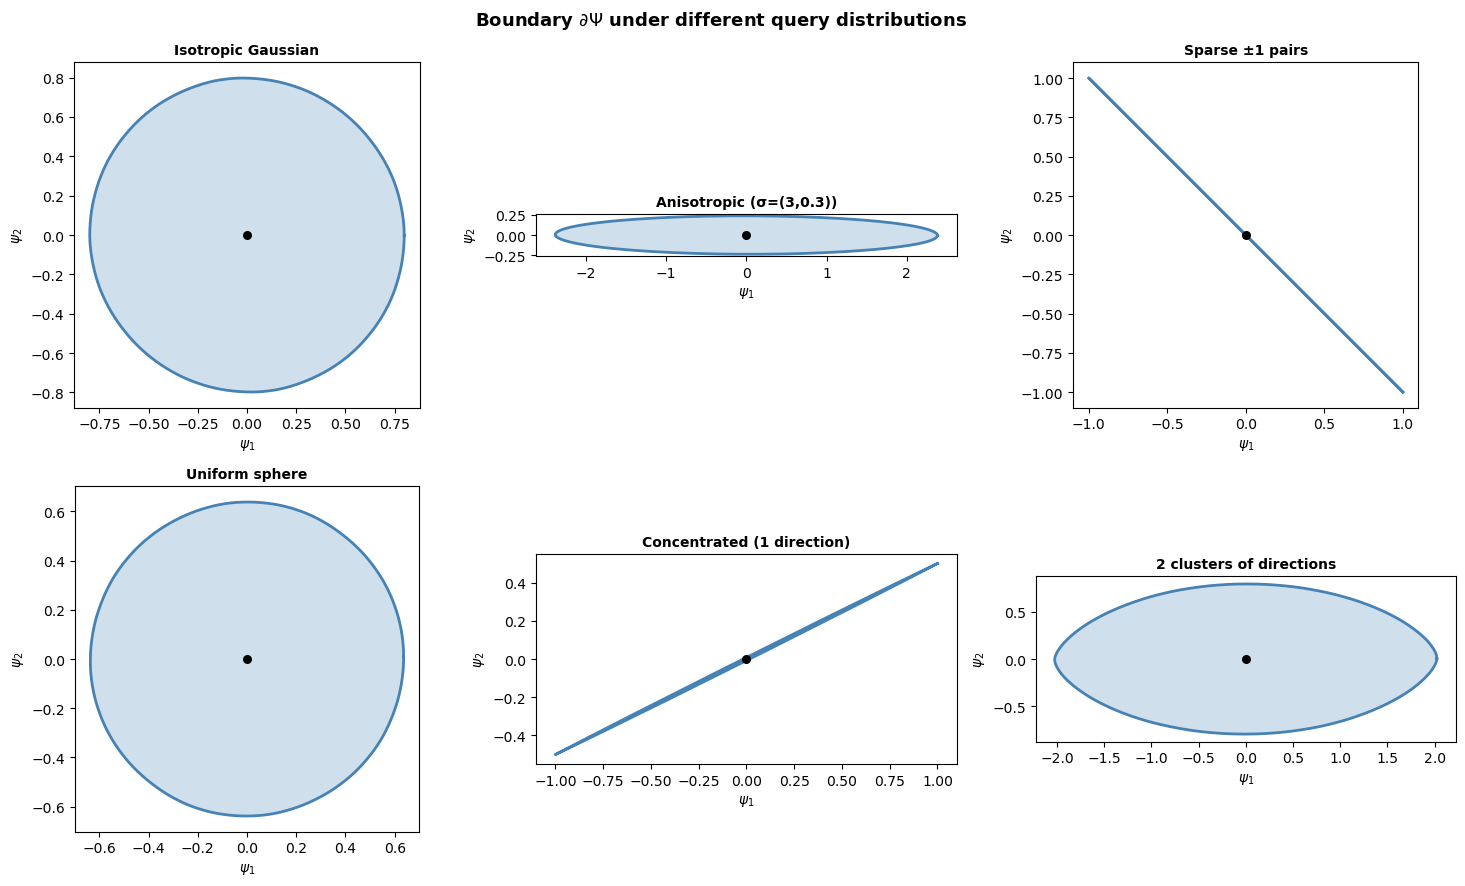

In [8]:
k_q, Q_q = 2, 8000
angles_bdy = np.linspace(0, 2*np.pi, 1000, endpoint=False)
big_R = 500
unit_bdy = np.c_[np.cos(angles_bdy), np.sin(angles_bdy)]

configs = [
    ("Isotropic Gaussian",     make_query_dist(k_q, Q_q, kind="gaussian",     seed=0)),
    ("Anisotropic (σ=(3,0.3))", np.random.default_rng(1).standard_normal((Q_q, k_q)) * np.array([3.0, 0.3])),
    ("Sparse ±1 pairs",         make_query_dist(k_q, Q_q, kind="sparse",       seed=2)),
    ("Uniform sphere",          make_query_dist(k_q, Q_q, kind="uniform_sphere",seed=3)),
    ("Concentrated (1 direction)", np.tile(np.array([[1.0, 0.5]]), (Q_q, 1)) + 0.01 * np.random.default_rng(4).standard_normal((Q_q, k_q))),
    ("2 clusters of directions",   np.vstack([
        np.random.default_rng(5).standard_normal((Q_q//2, k_q)) + np.array([2, 0]),
        np.random.default_rng(6).standard_normal((Q_q//2, k_q)) + np.array([-2, 0])
    ])),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (title, A_q) in zip(axes.ravel(), configs):
    bdy_psi = psi_batch(big_R * unit_bdy, A_q)
    ax.fill(bdy_psi[:, 0], bdy_psi[:, 1], alpha=0.25, color='steelblue')
    ax.plot(np.append(bdy_psi[:, 0], bdy_psi[0, 0]),
            np.append(bdy_psi[:, 1], bdy_psi[0, 1]),
            'steelblue', lw=2)
    ax.scatter([0], [0], c='black', s=30, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")

plt.suptitle(r"Boundary $\partial\Psi$ under different query distributions",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Is Ψ convex?

In [9]:
# Test convexity: for each pair of boundary points p1, p2,
# check whether the midpoint (p1+p2)/2 lies in Ψ.
# If ψ is injective and Ψ is connected, midpoint lies in Ψ iff
# it is achievable — we check by inverting ψ numerically (gradient descent).

from scipy.optimize import minimize

def psi_inv(target, A, theta_init=None, tol=1e-8):
    """Find θ s.t. ψ(θ) ≈ target via L-BFGS."""
    k_ = A.shape[1]
    if theta_init is None:
        theta_init = np.zeros(k_)
    def loss(th):
        diff = psi(th, A) - target
        return 0.5 * diff @ diff
    def grad(th):
        diff = psi(th, A) - target
        v_ = sigmoid(A @ th) * (1 - sigmoid(A @ th))
        J_ = 2 * (A * v_[:, None]).T @ A / len(A)
        return J_ @ diff
    res = minimize(loss, theta_init, jac=grad, method='L-BFGS-B',
                   options={'maxiter': 2000, 'ftol': tol**2})
    return res.x, res.fun

k_cv, Q_cv = 2, 5000
A_cv = make_query_dist(k_cv, Q_cv, kind="gaussian")

# Sample boundary points
n_pairs = 20
bdy_angles = rng.uniform(0, 2*np.pi, n_pairs * 2)
bdy_thetas = 500 * np.c_[np.cos(bdy_angles), np.sin(bdy_angles)]
bdy_pts    = psi_batch(bdy_thetas, A_cv)

residuals = []
for i in range(n_pairs):
    mid = (bdy_pts[2*i] + bdy_pts[2*i+1]) / 2
    _, res = psi_inv(mid, A_cv)
    residuals.append(res)

residuals = np.array(residuals)
print("Midpoint inversion residuals (near 0 → midpoint is in Ψ → Ψ is convex):")
print(np.round(residuals, 8))
print(f"Max residual: {residuals.max():.2e}")
print(f"Ψ appears {'convex' if residuals.max() < 1e-4 else 'NOT convex'} for Gaussian queries.")

Midpoint inversion residuals (near 0 → midpoint is in Ψ → Ψ is convex):
[0.000e+00 2.195e-05 1.110e-06 0.000e+00 0.000e+00 0.000e+00 6.000e-08
 0.000e+00 0.000e+00 0.000e+00 5.300e-07 0.000e+00 0.000e+00 0.000e+00
 3.670e-06 5.840e-06 1.370e-06 0.000e+00 0.000e+00 0.000e+00]
Max residual: 2.20e-05
Ψ appears convex for Gaussian queries.


## 9. Inverting ψ: mapping from impact space back to parameter space

Round-trip error ||θ_recovered − θ_true||:
  mean=5.61e-03  max=8.94e-02
  (near 0 confirms ψ is invertible in practice)


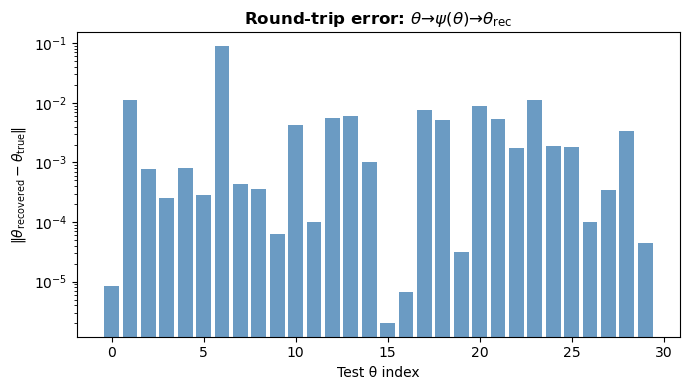

In [10]:
# ── Round-trip: θ → ψ(θ) → θ_recovered ──────────────────────────────────
k_rt, Q_rt = 4, 8000
A_rt = make_query_dist(k_rt, Q_rt, kind="gaussian")

n_test = 30
thetas_true = rng.standard_normal((n_test, k_rt)) * rng.uniform(0.1, 5, (n_test, 1))
errors = []
for th in thetas_true:
    target = psi(th, A_rt)
    th_rec, res = psi_inv(target, A_rt)
    errors.append(np.linalg.norm(th_rec - th))

errors = np.array(errors)
print("Round-trip error ||θ_recovered − θ_true||:")
print(f"  mean={errors.mean():.2e}  max={errors.max():.2e}")
print(f"  (near 0 confirms ψ is invertible in practice)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(n_test), errors, color='steelblue', alpha=0.8)
ax.set_xlabel("Test θ index")
ax.set_ylabel(r"$\|\theta_{\mathrm{recovered}} - \theta_{\mathrm{true}}\|$")
ax.set_title(r"Round-trip error: $\theta \to \psi(\theta) \to \theta_{\mathrm{rec}}$",
             fontweight="bold")
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 10. Inverse map ψ⁻¹: how a regular grid in Ψ looks in θ-space

Draw a polar grid (iso-radius circles + iso-angle rays) inside $\Psi$, then pull each node back to $\theta$-space via numerical inversion. The resulting warped grid reveals how $\psi$ compresses/stretches space: **near the boundary**, where $v(\alpha^\top\theta) \to 0$ and $J(\theta)$ becomes small, a tiny step in $\psi$-space requires a huge step in $\theta$-space.

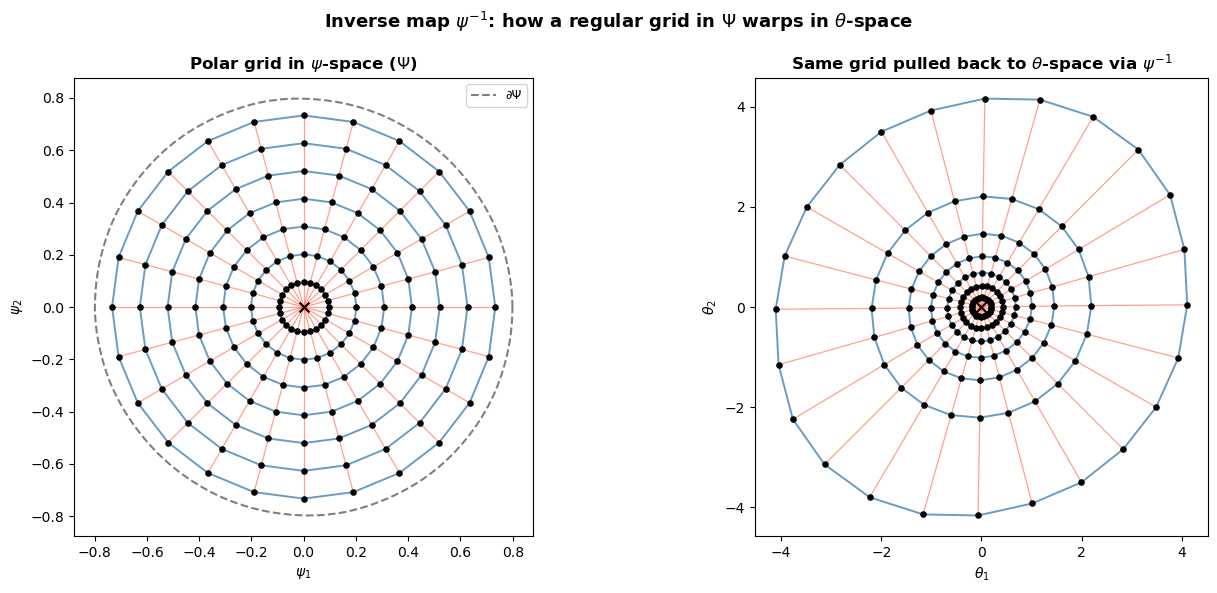

: 

In [ ]:
# ── Inverse map: polar grid in ψ-space → θ-space ─────────────────────────
k2, Q2 = 2, 8000
A2 = make_query_dist(k2, Q2, kind="gaussian", seed=0)

# Boundary for reference
angles_fine = np.linspace(0, 2*np.pi, 500, endpoint=False)
bdy_psi = psi_batch(500 * np.c_[np.cos(angles_fine), np.sin(angles_fine)], A2)
bdy_r = np.linalg.norm(bdy_psi, axis=1).mean()   # ≈ radius of ∂Ψ

# Polar grid in ψ-space: n_r iso-radius circles × n_a iso-angle rays
n_r, n_a = 7, 24
radii_grid  = np.linspace(0.12, 0.92, n_r) * bdy_r
angles_grid = np.linspace(0, 2*np.pi, n_a, endpoint=False)

psi_polar = np.array([[[r * np.cos(a), r * np.sin(a)]
                        for a in angles_grid]
                       for r in radii_grid])   # (n_r, n_a, 2)

# Numerically invert each grid node
theta_polar = np.zeros_like(psi_polar)
for i in range(n_r):
    for j in range(n_a):
        th, _ = psi_inv(psi_polar[i, j], A2)
        theta_polar[i, j] = th

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, grid, space in zip(axes, [psi_polar, theta_polar], ["psi", "theta"]):
    # iso-radius curves (closed loops at fixed r)
    for i in range(n_r):
        pts = np.vstack([grid[i], grid[i, 0]])   # close the loop
        ax.plot(pts[:, 0], pts[:, 1], color='steelblue', lw=1.4, alpha=0.8)

    # iso-angle rays (from origin outward at fixed angle)
    for j in range(n_a):
        pts = np.vstack([[[0, 0]], grid[:, j]])
        ax.plot(pts[:, 0], pts[:, 1], color='tomato', lw=0.9, alpha=0.6)

    ax.scatter(grid.reshape(-1, 2)[:, 0], grid.reshape(-1, 2)[:, 1],
               s=14, c='black', zorder=5)
    ax.scatter([0], [0], c='black', s=50, zorder=6, marker='x')

    if space == "psi":
        ax.plot(np.append(bdy_psi[:, 0], bdy_psi[0, 0]),
                np.append(bdy_psi[:, 1], bdy_psi[0, 1]),
                'k--', lw=1.5, alpha=0.5, label='∂Ψ')
        ax.legend(fontsize=9)
        ax.set_title(r"Polar grid in $\psi$-space ($\Psi$)", fontweight='bold')
        ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    else:
        ax.set_title(r"Same grid pulled back to $\theta$-space via $\psi^{-1}$", fontweight='bold')
        ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")

    ax.set_aspect('equal')

plt.suptitle(r"Inverse map $\psi^{-1}$: how a regular grid in $\Psi$ warps in $\theta$-space",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Preimage of regions: ψ⁻¹(B) in θ-space

Pick three small disk-shaped regions in $\Psi$ — one at the center, one midway, one near the boundary — and find all $\theta$ that map into each. The preimage shape reveals how the fiber of $\psi$ grows and distorts as you approach $\partial\Psi$: near the boundary, $J(\theta)$ is small so the preimage becomes **very elongated radially** (many $\theta$ values produce nearly the same impact).

In [2]:
# ── Preimage of regions in θ-space ───────────────────────────────────────
# (reuses A2 and bdy_r from cell above — run that cell first)

# Three small disks in ψ-space: center, mid, near boundary (all on x-axis)
r_region = 0.07 * bdy_r
region_centers = np.array([
    [0.0,         0.0],
    [0.48 * bdy_r, 0.0],
    [0.87 * bdy_r, 0.0],
])
region_colors = ['#4878CF', '#E24A33', '#56A55B']
region_labels  = ['Center (ψ=0)', 'Mid', 'Near boundary']

# Dense θ sweep over [-8, 8]²
n_dense = 500
th_vals = np.linspace(-8, 8, n_dense)
TH1, TH2 = np.meshgrid(th_vals, th_vals)
thetas_flat = np.c_[TH1.ravel(), TH2.ravel()]   # (n_dense², 2)
psi_flat    = psi_batch(thetas_flat, A2)          # (n_dense², 2)

# Assign each θ to a region (or background)
assignments = np.full(len(thetas_flat), -1)
for k_r, center in enumerate(region_centers):
    mask = np.linalg.norm(psi_flat - center, axis=1) < r_region
    assignments[mask] = k_r

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: regions drawn on Ψ
ax = axes[0]
ax.fill(bdy_psi[:, 0], bdy_psi[:, 1], color='whitesmoke', zorder=0)
ax.plot(np.append(bdy_psi[:, 0], bdy_psi[0, 0]),
        np.append(bdy_psi[:, 1], bdy_psi[0, 1]),
        'k--', lw=1.5)
for center, color, label in zip(region_centers, region_colors, region_labels):
    circle = plt.Circle(center, r_region, color=color, alpha=0.75, zorder=3, label=label)
    ax.add_patch(circle)
ax.scatter([0], [0], c='black', s=30, zorder=5)
lim = 1.15 * bdy_r
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_title(r"Three regions in $\psi$-space ($\Psi$)", fontweight='bold')
ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
ax.legend(fontsize=9, loc='upper left')

# Right: preimage in θ-space
ax = axes[1]
ax.scatter(thetas_flat[assignments == -1, 0], thetas_flat[assignments == -1, 1],
           c='lightgray', s=0.2, alpha=0.12, rasterized=True)
for k_r, (color, label) in enumerate(zip(region_colors, region_labels)):
    mask = assignments == k_r
    ax.scatter(thetas_flat[mask, 0], thetas_flat[mask, 1],
               c=color, s=2, alpha=0.9, label=f"{label} ({mask.sum()} pts)",
               rasterized=True)
ax.scatter([0], [0], c='black', s=50, zorder=6, marker='x')
ax.set_aspect('equal')
ax.set_title(r"Preimage $\psi^{-1}(\text{region})$ in $\theta$-space", fontweight='bold')
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")
ax.legend(markerscale=6, fontsize=9)

plt.suptitle(r"Preimage of small regions under $\psi$ — how the fiber grows near $\partial\Psi$",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Print size ratio as a simple measure of fiber expansion
counts = [(assignments == k_r).sum() for k_r in range(3)]
print("Preimage sizes (number of θ grid points in each region's preimage):")
for label, n in zip(region_labels, counts):
    print(f"  {label:25s}: {n:6d}")

NameError: name 'bdy_r' is not defined